In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import joblib
import streamlit

print("All libraries working!")

All libraries working!


Step 1: Import Libraries

In [6]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

Step 2: Load the Dataset

In [10]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("..\data\Dataset.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


Step 3: View the Dataset

In [11]:
# Display first five rows

df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


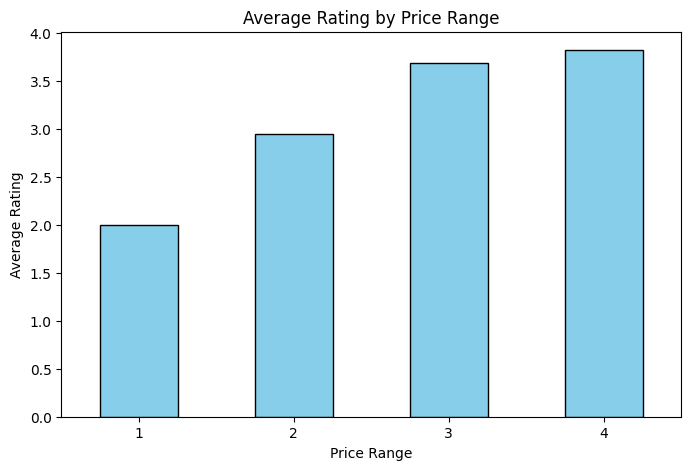

In [12]:
import matplotlib.pyplot as plt

avg_rating = df.groupby("Price range")["Aggregate rating"].mean()

plt.figure(figsize=(8,5))

avg_rating.plot(
    kind="bar",
    color="skyblue",
    edgecolor="black"
)

plt.title("Average Rating by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average Rating")
plt.xticks(rotation=0)
plt.savefig("../assets/images/price_vs_rating.png", dpi=300)

plt.show()

Step 4: Check Dataset Information

In [6]:
# Basic information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

Step 5: Check Dataset Shape

In [7]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 9551
Columns : 21


Step 6: Check Missing Values

In [8]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

Step 7: Check Duplicate Records

In [9]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


Exploratory Data Analysis (EDA)

Step 1: Summary Statistics

Step 2: Missing Values Visualization

Step 3: Distribution of Ratings

Step 4: Top 10 Cities

Step 5: Most Popular Cuisines

Step 6: Votes vs Rating

Step 7: Price Range vs Rating

Step 8: Correlation Matrix


In [10]:
# Summary statistics for numerical columns
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


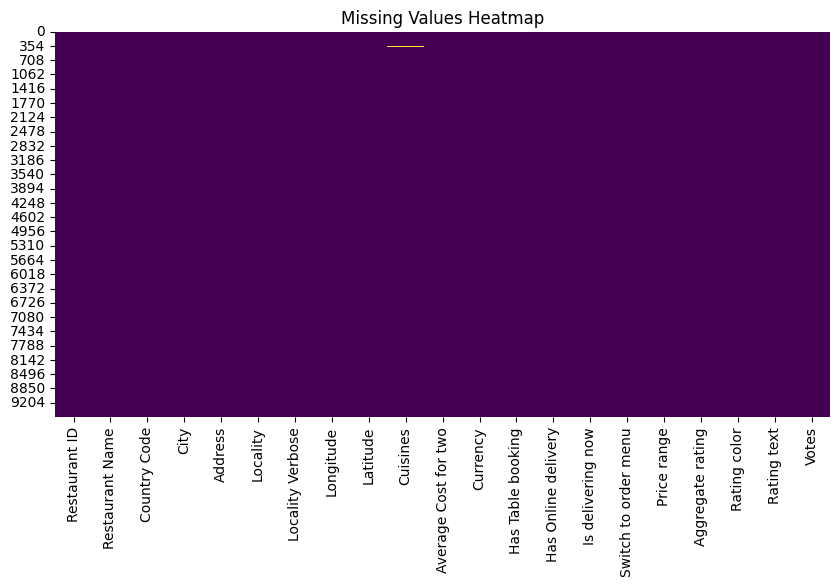

In [11]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")

plt.title("Missing Values Heatmap")
plt.show()

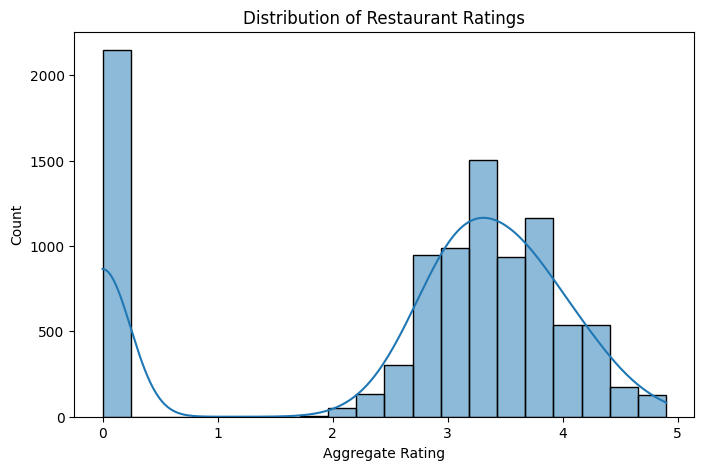

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["Aggregate rating"], bins=20, kde=True)

plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Aggregate Rating")
plt.ylabel("Count")

plt.show()

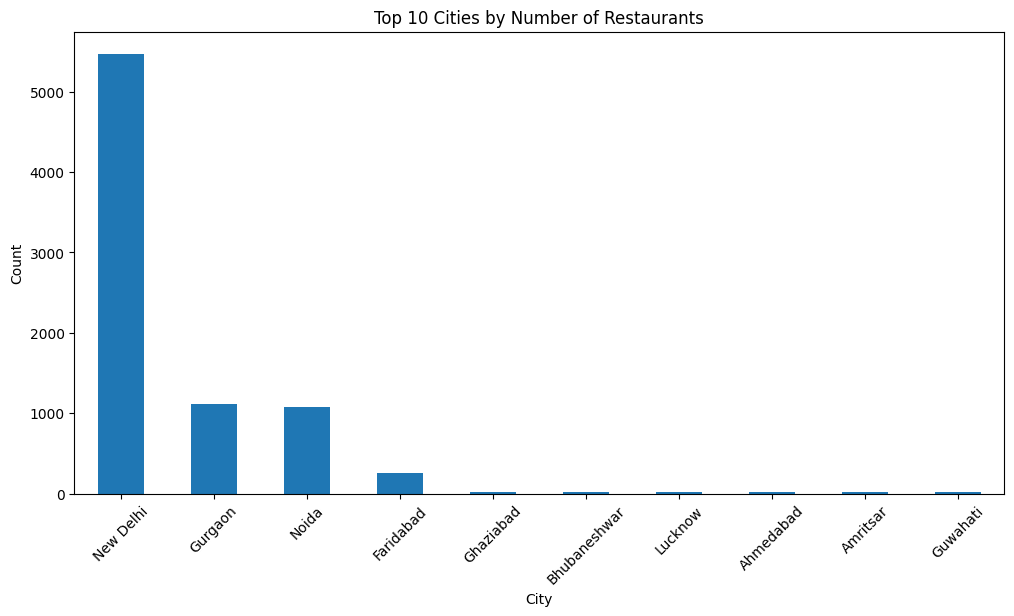

In [13]:
plt.figure(figsize=(12,6))

df["City"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("City")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

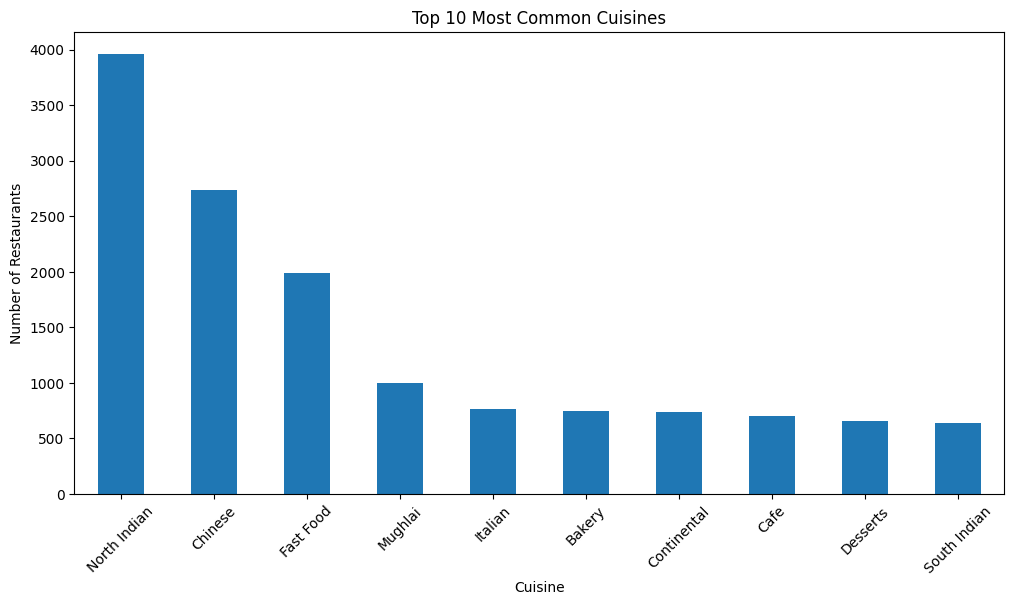

In [14]:
top_cuisines = (
    df["Cuisines"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

top_cuisines.plot(kind="bar")

plt.title("Top 10 Most Common Cuisines")
plt.xlabel("Cuisine")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=45)

plt.show()

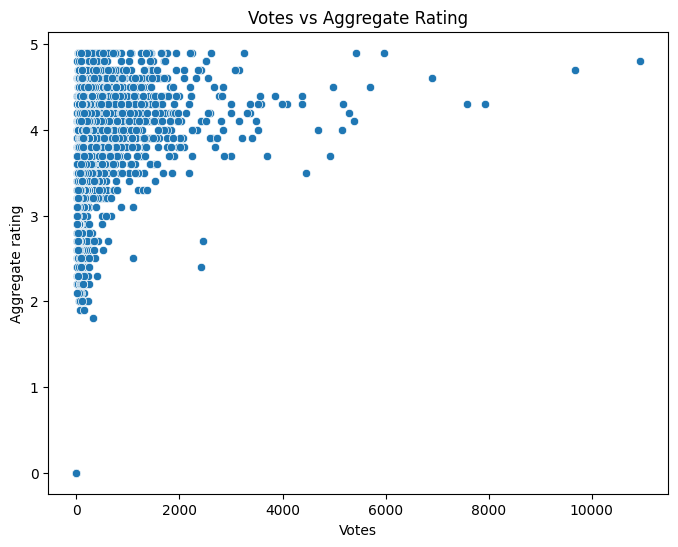

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Votes",
    y="Aggregate rating",
    data=df
)

plt.title("Votes vs Aggregate Rating")

plt.show()

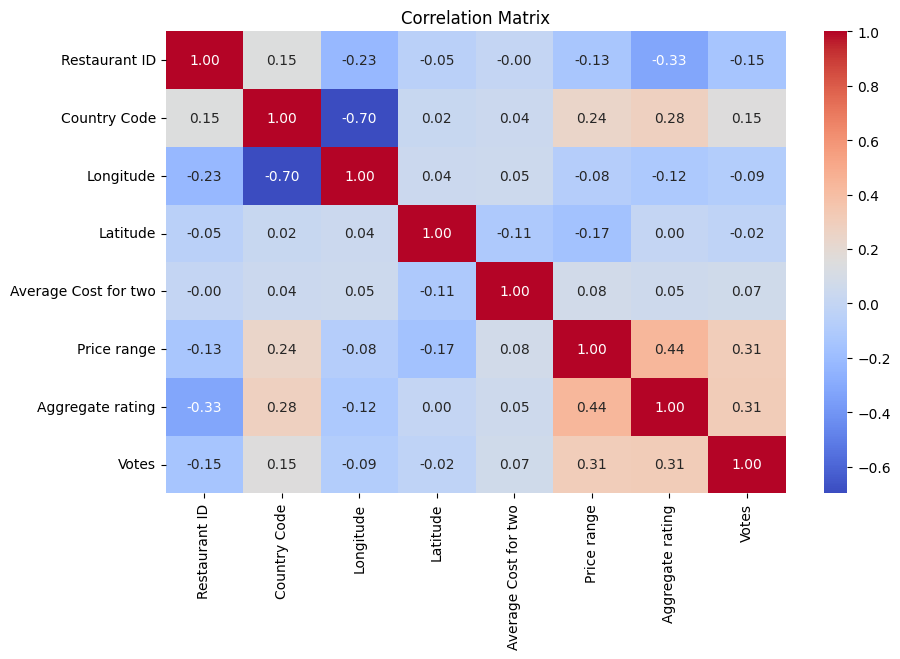

In [16]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=["number"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

3 Data Cleaning & Preprocessing

Step 1: Handle Missing Values

step 2: Drop Unnecessary Columns

Step 3: Encode Categorical Features

Convert text columns like City, Currency, Cuisines, etc., into numerical values using LabelEncoder.

Step 4: Split Features and Target

Step 5: Train-Test Split



In [17]:
df["Cuisines"].fillna("Unknown", inplace=True)

In [18]:
columns_to_drop = [
    "Restaurant ID",
    "Restaurant Name",
    "Address",
    "Locality",
    "Locality Verbose",
    "Rating color",
    "Rating text"
]

df = df.drop(columns=columns_to_drop)

In [25]:
# ==========================================
# Encode Categorical Variables
# ==========================================

from sklearn.preprocessing import LabelEncoder

# Create a copy of the dataframe
df_encoded = df.copy()

# Initialize LabelEncoder
le = LabelEncoder()

# Encode all categorical columns
categorical_columns = df_encoded.select_dtypes(include=['object']).columns

for col in categorical_columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# Verify that all object columns are encoded
print(df_encoded.select_dtypes(include=['object']).columns)

Index([], dtype='object')


In [26]:
X = df_encoded.drop("Aggregate rating", axis=1)
y = df_encoded["Aggregate rating"]

In [19]:
X = df.drop("Aggregate rating", axis=1)
y = df["Aggregate rating"]

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

phase 4: Model Training

We'll train three different regression models and compare them.

Step 6: Linear Regression, Decision Tree Regressor,Random Forest Regressor

In [28]:
X.select_dtypes(include="object").columns

Index([], dtype='object')

In [29]:
# ==========================================
# Linear Regression
# ==========================================

from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


In [30]:
# ==========================================
# Decision Tree Regressor
# ==========================================

from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Model Trained Successfully!")

Decision Tree Model Trained Successfully!


In [31]:
# ==========================================
# Random Forest Regressor
# ==========================================

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


Phase 5: Model Evaluation

Evaluate Linear Regression,Random Forest Regressor,Decision Tree Regressor

Compare Models in a Table

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(model_name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print("="*40)
    print(model_name)
    print("="*40)

    print(f"MAE  : {mae:.3f}")
    print(f"MSE  : {mse:.3f}")
    print(f"RMSE : {rmse:.3f}")
    print(f"R²   : {r2:.3f}")

In [33]:
evaluate_model("Linear Regression", y_test, lr_pred)

Linear Regression
MAE  : 1.048
MSE  : 1.586
RMSE : 1.259
R²   : 0.303


In [34]:
evaluate_model("Decision Tree", y_test, dt_pred)

Decision Tree
MAE  : 0.271
MSE  : 0.176
RMSE : 0.420
R²   : 0.923


In [35]:
evaluate_model("Random Forest", y_test, rf_pred)

Random Forest
MAE  : 0.192
MSE  : 0.087
RMSE : 0.296
R²   : 0.962


In [36]:
results = pd.DataFrame({
    "Model": ["Linear Regression",
              "Decision Tree",
              "Random Forest"],

    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, dt_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ]
})

results.sort_values("R2 Score", ascending=False)

,Model,R2 Score,RMSE
2,Random Forest,0.961580,0.295715
1,Decision Tree,0.922681,0.419507
0,Linear Regression,0.303112,1.259441


In [37]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
12,Votes,0.947476
2,Longitude,0.015274
3,Latitude,0.011814
4,Cuisines,0.010410
5,Average Cost for two,0.006682
0,Country Code,0.003242
1,City,0.001776
8,Has Online delivery,0.001139
11,Price range,0.000936
6,Currency,0.000662


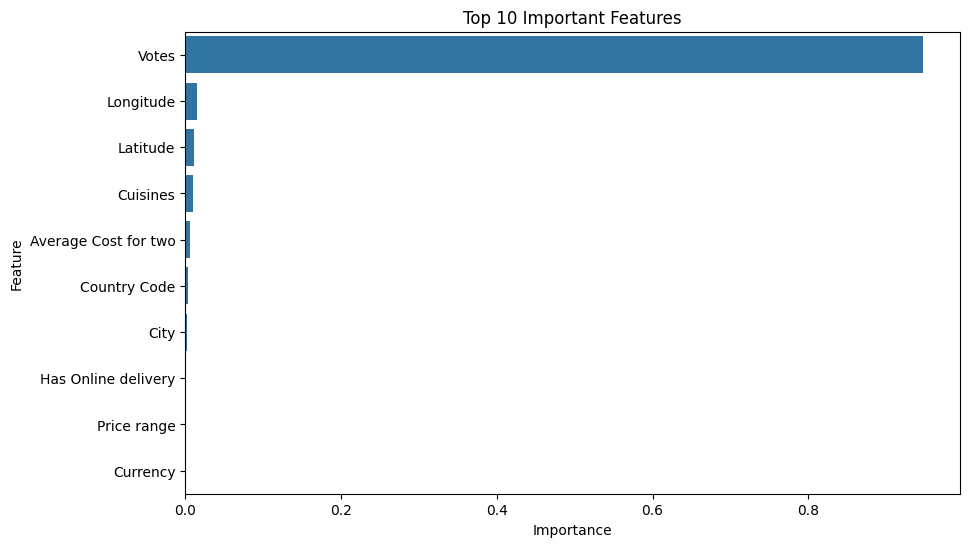

In [38]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

Save the Encoders Too

Since we encoded categorical columns, save the encoders so the Streamlit app can use them later.

Replace your encoding section with this version (or run it again before training):

In [39]:
import joblib

joblib.dump(rf_model, "../models/restaurant_rating_model.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [40]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

df_encoded = df.copy()

for col in df_encoded.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

In [41]:
joblib.dump(label_encoders, "../models/label_encoders.pkl")

['../models/label_encoders.pkl']